In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import chi2_contingency

# Feature description:

- Age: age
- Gender: gender
- Country: country
- state: If you live in the United States, which state or territory do you live in?
- self_employed: Are you self-employed?
- family_history: Do you have a family history of mental illness?
- treatment: Have you sought treatment for a mental health condition?
- work_interfere: If you have a mental health condition, do you feel that it interferes with your work?
- no_employees: How many employees does your company or organization have?
- remote_work: Do you work remotely (outside of an office) at least 50% of the time?
- tech_company: Is your employer primarily a tech company/organization?
- benefits: Does your employer provide mental health benefits?
- care_options: Do you know the options for mental health care your employer provides?
- wellness_program: Has your employer ever discussed mental health as part of an employee wellness program?
- seek_help: Does your employer provide resources to learn more about mental health issues and how to seek help?
- anonymity: Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources?
- leave: How easy is it for you to take medical leave for a mental health condition?
- mental_health_consequence: Do you think that discussing a mental health issue with your employer would have negative consequences?
- phys_health_consequence: Do you think that discussing a physical health issue with your employer would have negative consequences?
- coworkers: Would you be willing to discuss a mental health issue with your coworkers?
- supervisor: Would you be willing to discuss a mental health issue with your direct supervisor(s)?
- mental_health_interview: Would you bring up a mental health issue with a potential employer in an interview?
- phys_health_interview: Would you bring up a physical health issue with a potential employer in an interview?
- mental_vs_physical: Do you feel that your employer takes mental health as seriously as physical health?
- obs_consequence: Have you heard of or observed negative consequences for coworkers with mental health conditions in your workplace?

In [49]:
data = pd.read_csv("../data/cleaned.csv")
processed_data = pd.read_csv("../data/processed.csv")

In [50]:
binary_cols = [
    'treatment', 'family_history', 'remote_work', 'tech_company',
    'obs_consequence', 'benefits', 'care_options', 'wellness_program',
    'mental_vs_physical', 'seek_help', 'anonymity', 'self_employed'
]

ordinal_cols = [
    'no_employees', 'leave',
    'mental_health_consequence', 'phys_health_consequence',
    'mental_health_interview', 'phys_health_interview',
    'coworkers', 'supervisor'
]

numerical_cols = ['Age']

nominal_cols = ['Gender_clean', 'Country']

binary_nominal_cols = binary_cols + nominal_cols
all_features = binary_cols + ordinal_cols + numerical_cols + nominal_cols

target_col = 'work_interfere'

# Binary feature analysis

- distribution pie and bar plots
- Phi coefficient correlation matrix
- binary features vs target – stacked proportions (chi2)
- Cramér's V table

# Conclusions:
- relevant features: treatment, family_history, obs_consequence, benefits, care_options
- irrelevant: wellness_program, seek_help, anonymity, remote_work, tech_company

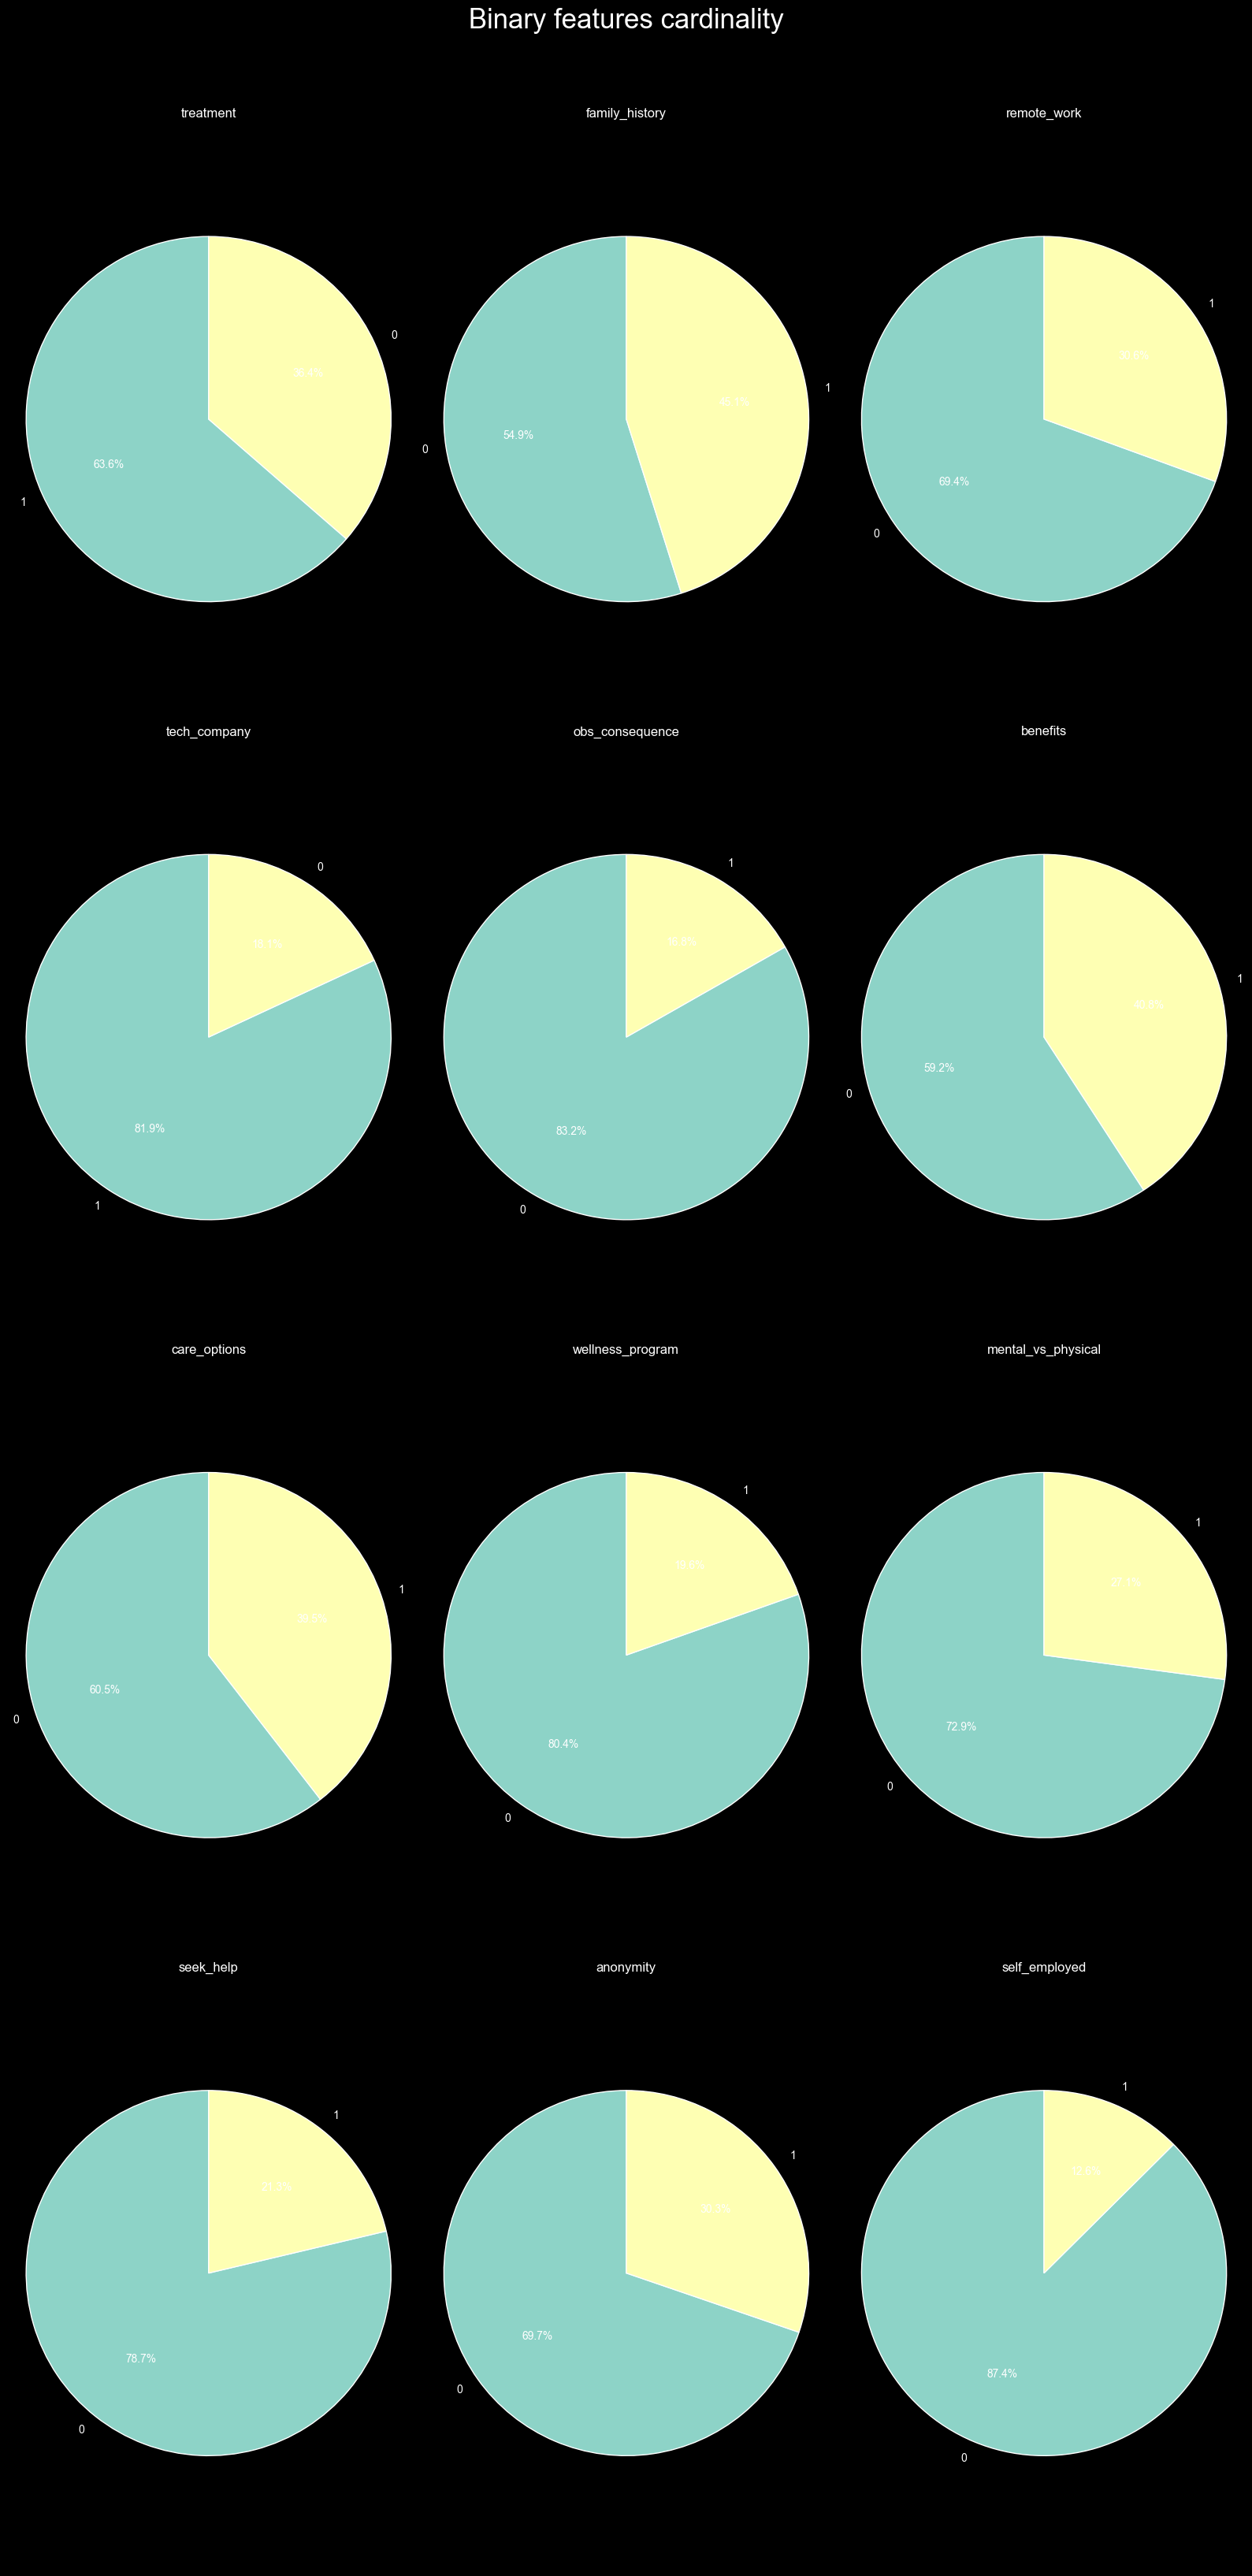

In [51]:
nrows, ncols = 4, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 32))
axes = axes.flat

for ax, col in zip(axes, binary_cols):
    sizes = data[col].value_counts()
    labels = sizes.index.astype(str)

    ax.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90)
    ax.set_title(col)
    ax.axis("equal")

fig.suptitle("Binary features cardinality", fontsize=25, y=1.02)
plt.tight_layout()
plt.show()

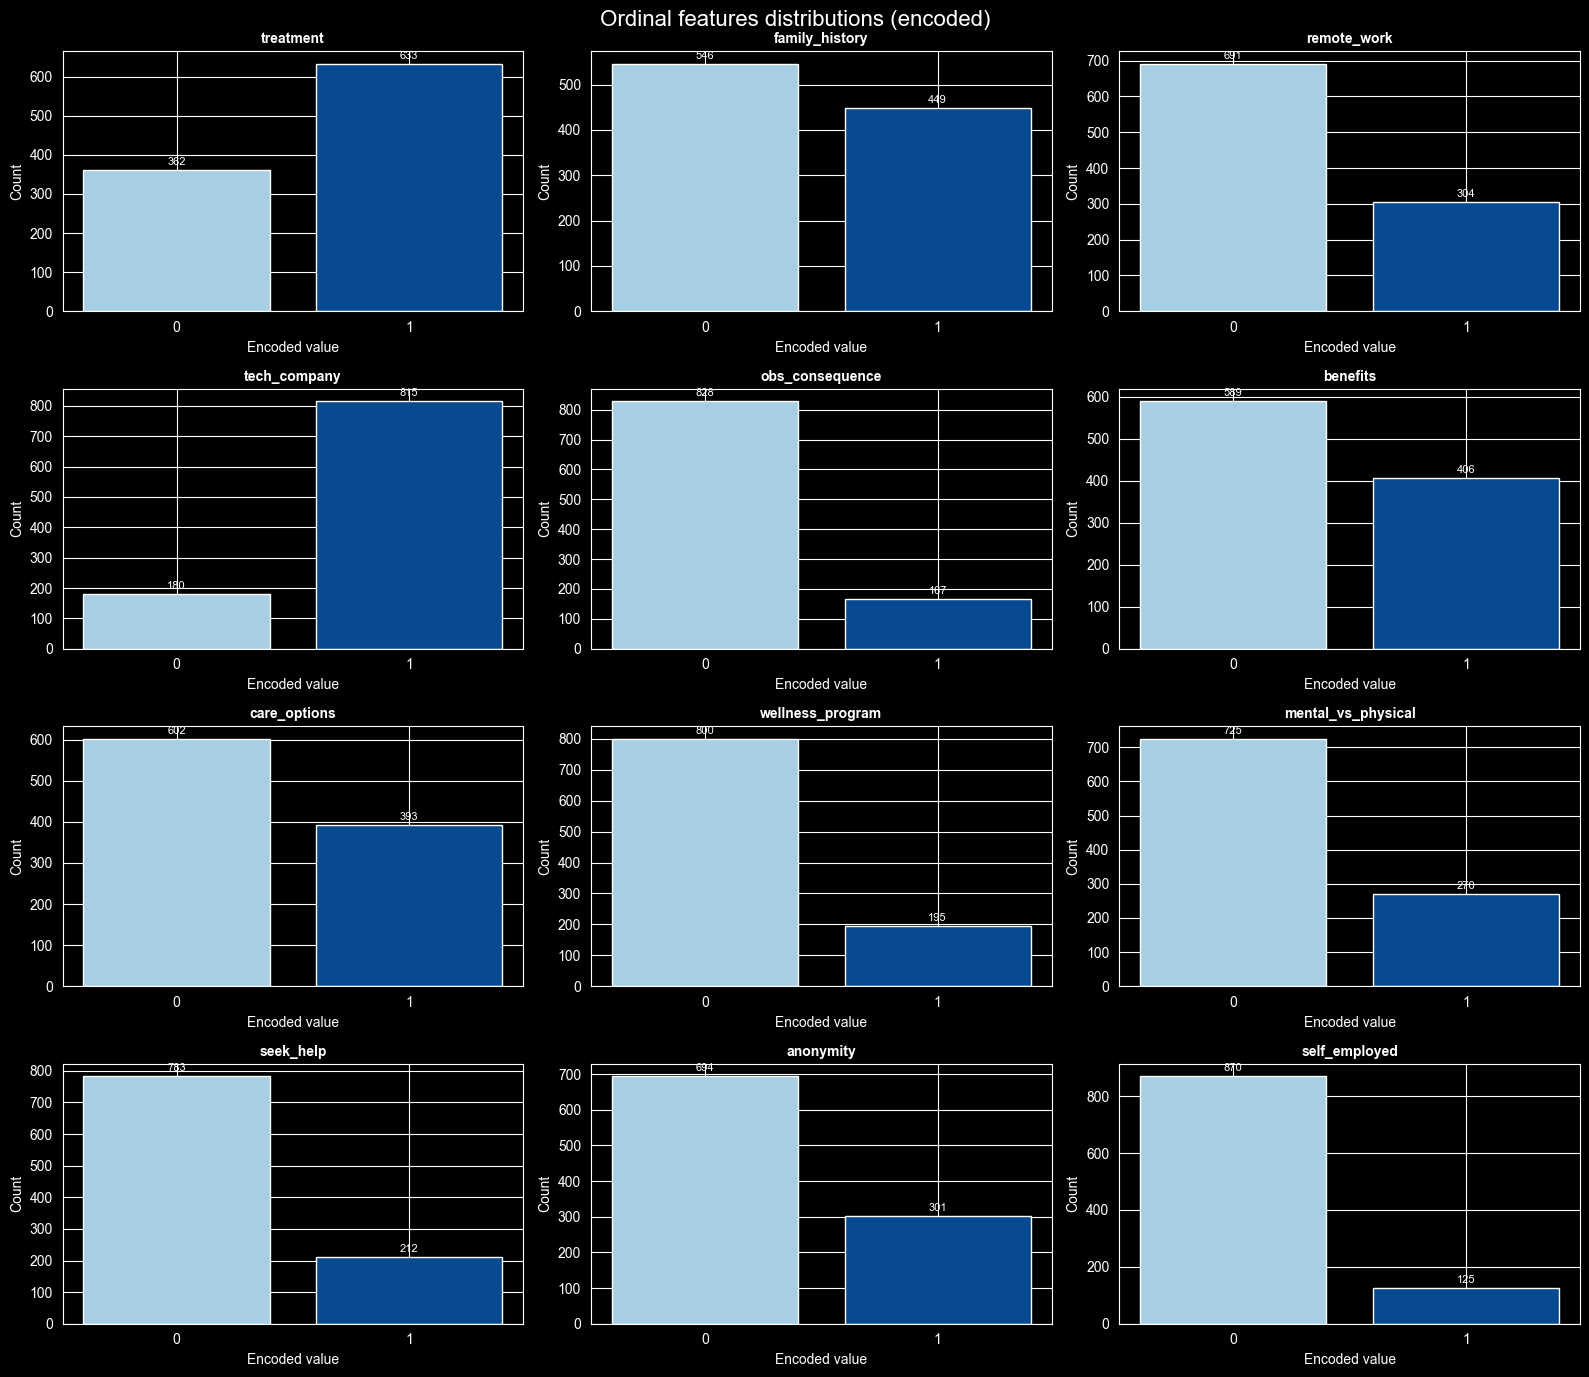

In [52]:
nrows, ncols = 4, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 14))
axes = axes.flat

for ax, col in zip(axes, binary_cols):
    counts = data[col].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values,
           color=plt.cm.Blues(np.linspace(0.35, 0.9, len(counts))),
           edgecolor="white")
    ax.set_title(col, fontsize=10, fontweight="bold")
    ax.set_ylabel("Count")
    ax.set_xlabel("Encoded value")
    for i, v in enumerate(counts.values):
        ax.text(i, v + counts.max() * 0.02, str(v), ha="center", fontsize=8)

fig.suptitle("Ordinal features distributions (encoded)", fontsize=16)
plt.tight_layout()
plt.show()

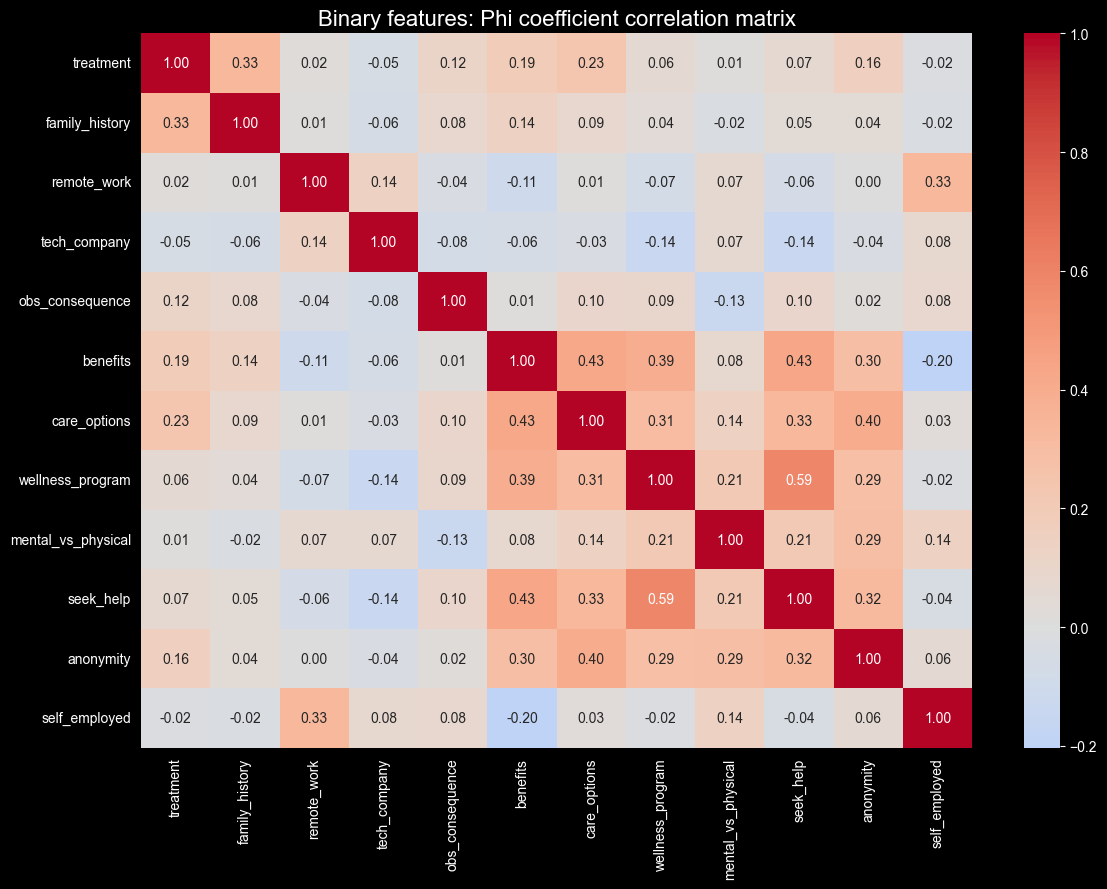

In [53]:
phi_matrix = data[binary_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))

sns.heatmap(phi_matrix, annot=True, fmt=".2f", cmap="coolwarm", center = 0, ax=ax)

ax.set_title("Binary features: Phi coefficient correlation matrix", fontsize=16)
plt.tight_layout()
plt.show()

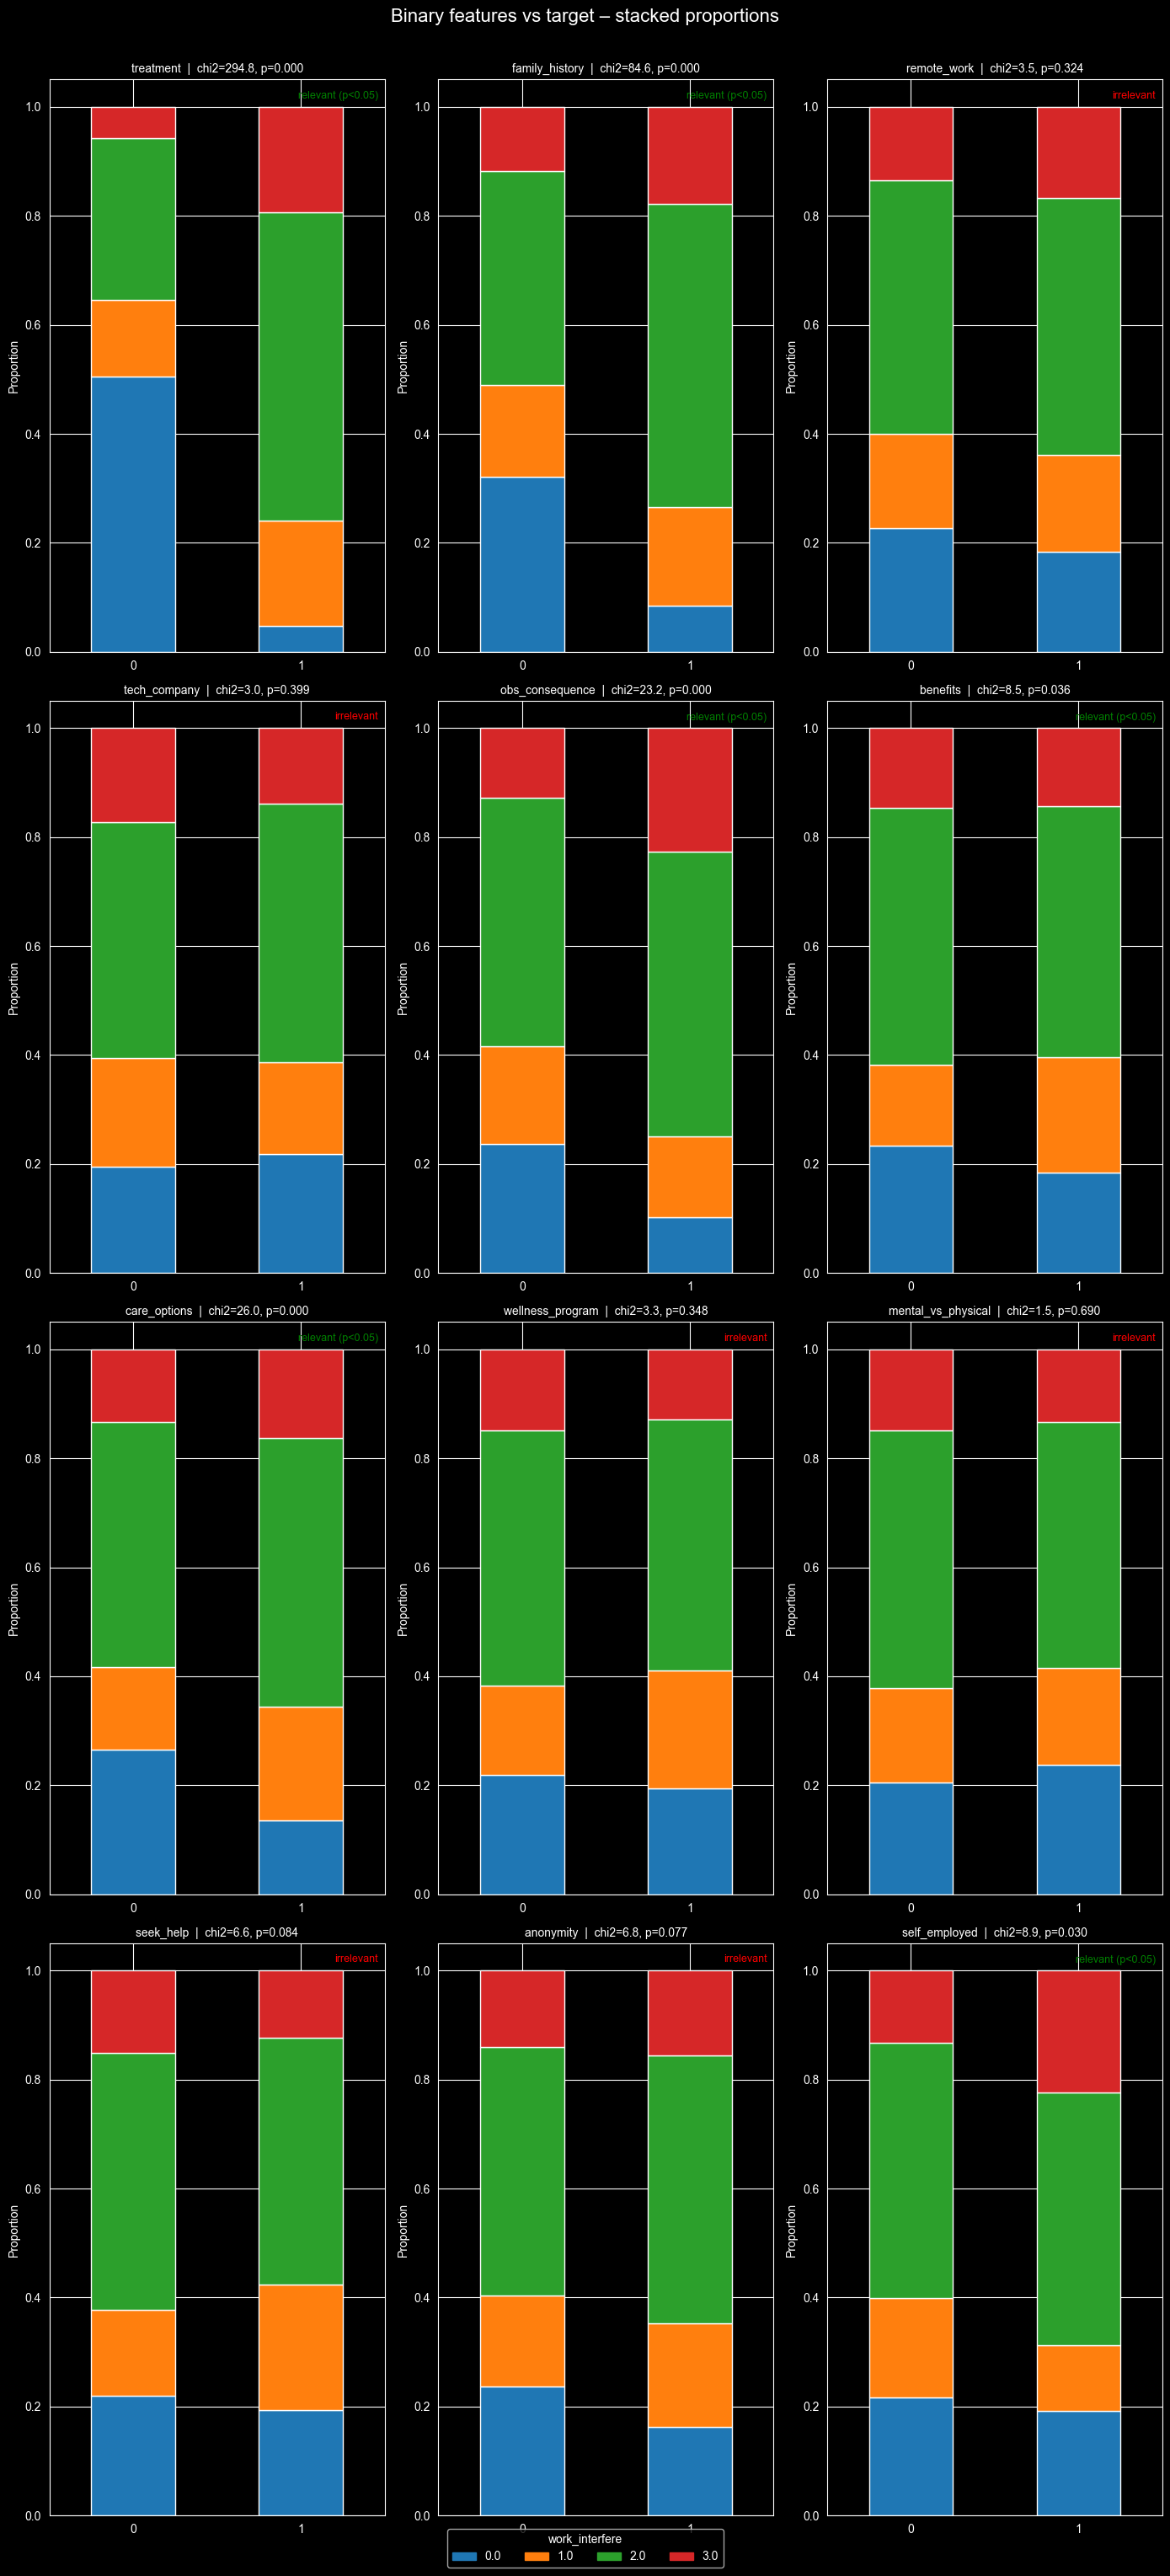

In [54]:
fig, axes = plt.subplots(4, 3, figsize=(14, 30))
axes = axes.flat

target_order = sorted(data[target_col].dropna().unique())
palette = sns.color_palette("tab10", len(target_order))

for ax, col in zip(axes, binary_cols):
    ct = (data.groupby(col)[target_col].value_counts(normalize=True).unstack(fill_value=0).reindex(columns=target_order))

    ct.plot(kind="bar", stacked=True, ax=ax, color=palette, edgecolor="white", legend=False)

    contingency = pd.crosstab(data[col], data[target_col])
    chi2, p, _, _ = chi2_contingency(contingency)

    ax.set_title(f"{col}  |  chi2={chi2:.1f}, p={p:.3f}", fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("Proportion")
    ax.tick_params(axis="x", rotation=0)
    ax.set_ylim(0, 1.05)

    significance = "relevant (p<0.05)" if p < 0.05 else "irrelevant"
    color = "green" if p < 0.05 else "red"
    ax.text(0.98, 0.98, significance, transform=ax.transAxes, ha="right", va="top", fontsize=9, color=color)

handles = [plt.Rectangle((0,0),1,1, color=palette[i]) for i in range(len(target_order))]

fig.legend(handles, [str(k) for k in target_order],title=target_col, loc="lower center",
           ncol=len(target_order), bbox_to_anchor=(0.5, -0.01))

fig.suptitle("Binary features vs target – stacked proportions", fontsize=16, y=1.005)
plt.tight_layout()
plt.show()

In [55]:
rows = []
for col in binary_cols:
    contingency = pd.crosstab(data[col], data[target_col])
    chi2, p, dof, _ = chi2_contingency(contingency)
    n = contingency.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
    rows.append({'feature': col, 'cramers_v': round(cramers_v, 3), 'p_value': round(p, 4)})

cramers_df = (pd.DataFrame(rows)
                .sort_values('cramers_v', ascending=False)
                .assign(relevant=lambda d: d['p_value'].apply(lambda p: 'yes' if p < 0.05 else 'no'))
                .reset_index(drop=True))

cramers_df

,feature,cramers_v,p_value,relevant
0,treatment,0.544,0.0000,yes
1,family_history,0.292,0.0000,yes
2,care_options,0.162,0.0000,yes
3,obs_consequence,0.153,0.0000,yes
4,self_employed,0.095,0.0303,yes
5,benefits,0.093,0.0363,yes
6,anonymity,0.083,0.0774,no
7,seek_help,0.082,0.0840,no
8,remote_work,0.059,0.3243,no
9,wellness_program,0.058,0.3481,no


In [56]:
#processed_data = processed_data.drop(['wellness_program', 'seek_help', 'anonymity', 'tech_company', 'remote_work'])

# Ordinal feature analysis

- distribution pie and bar plots
-

# Conclusions:

no_employees, leave, mental_health_consequence, phys_health_consequence,
mental_health_interview, phys_health_interview, coworkers, supervisor

- relevant features:
- irrelevant:

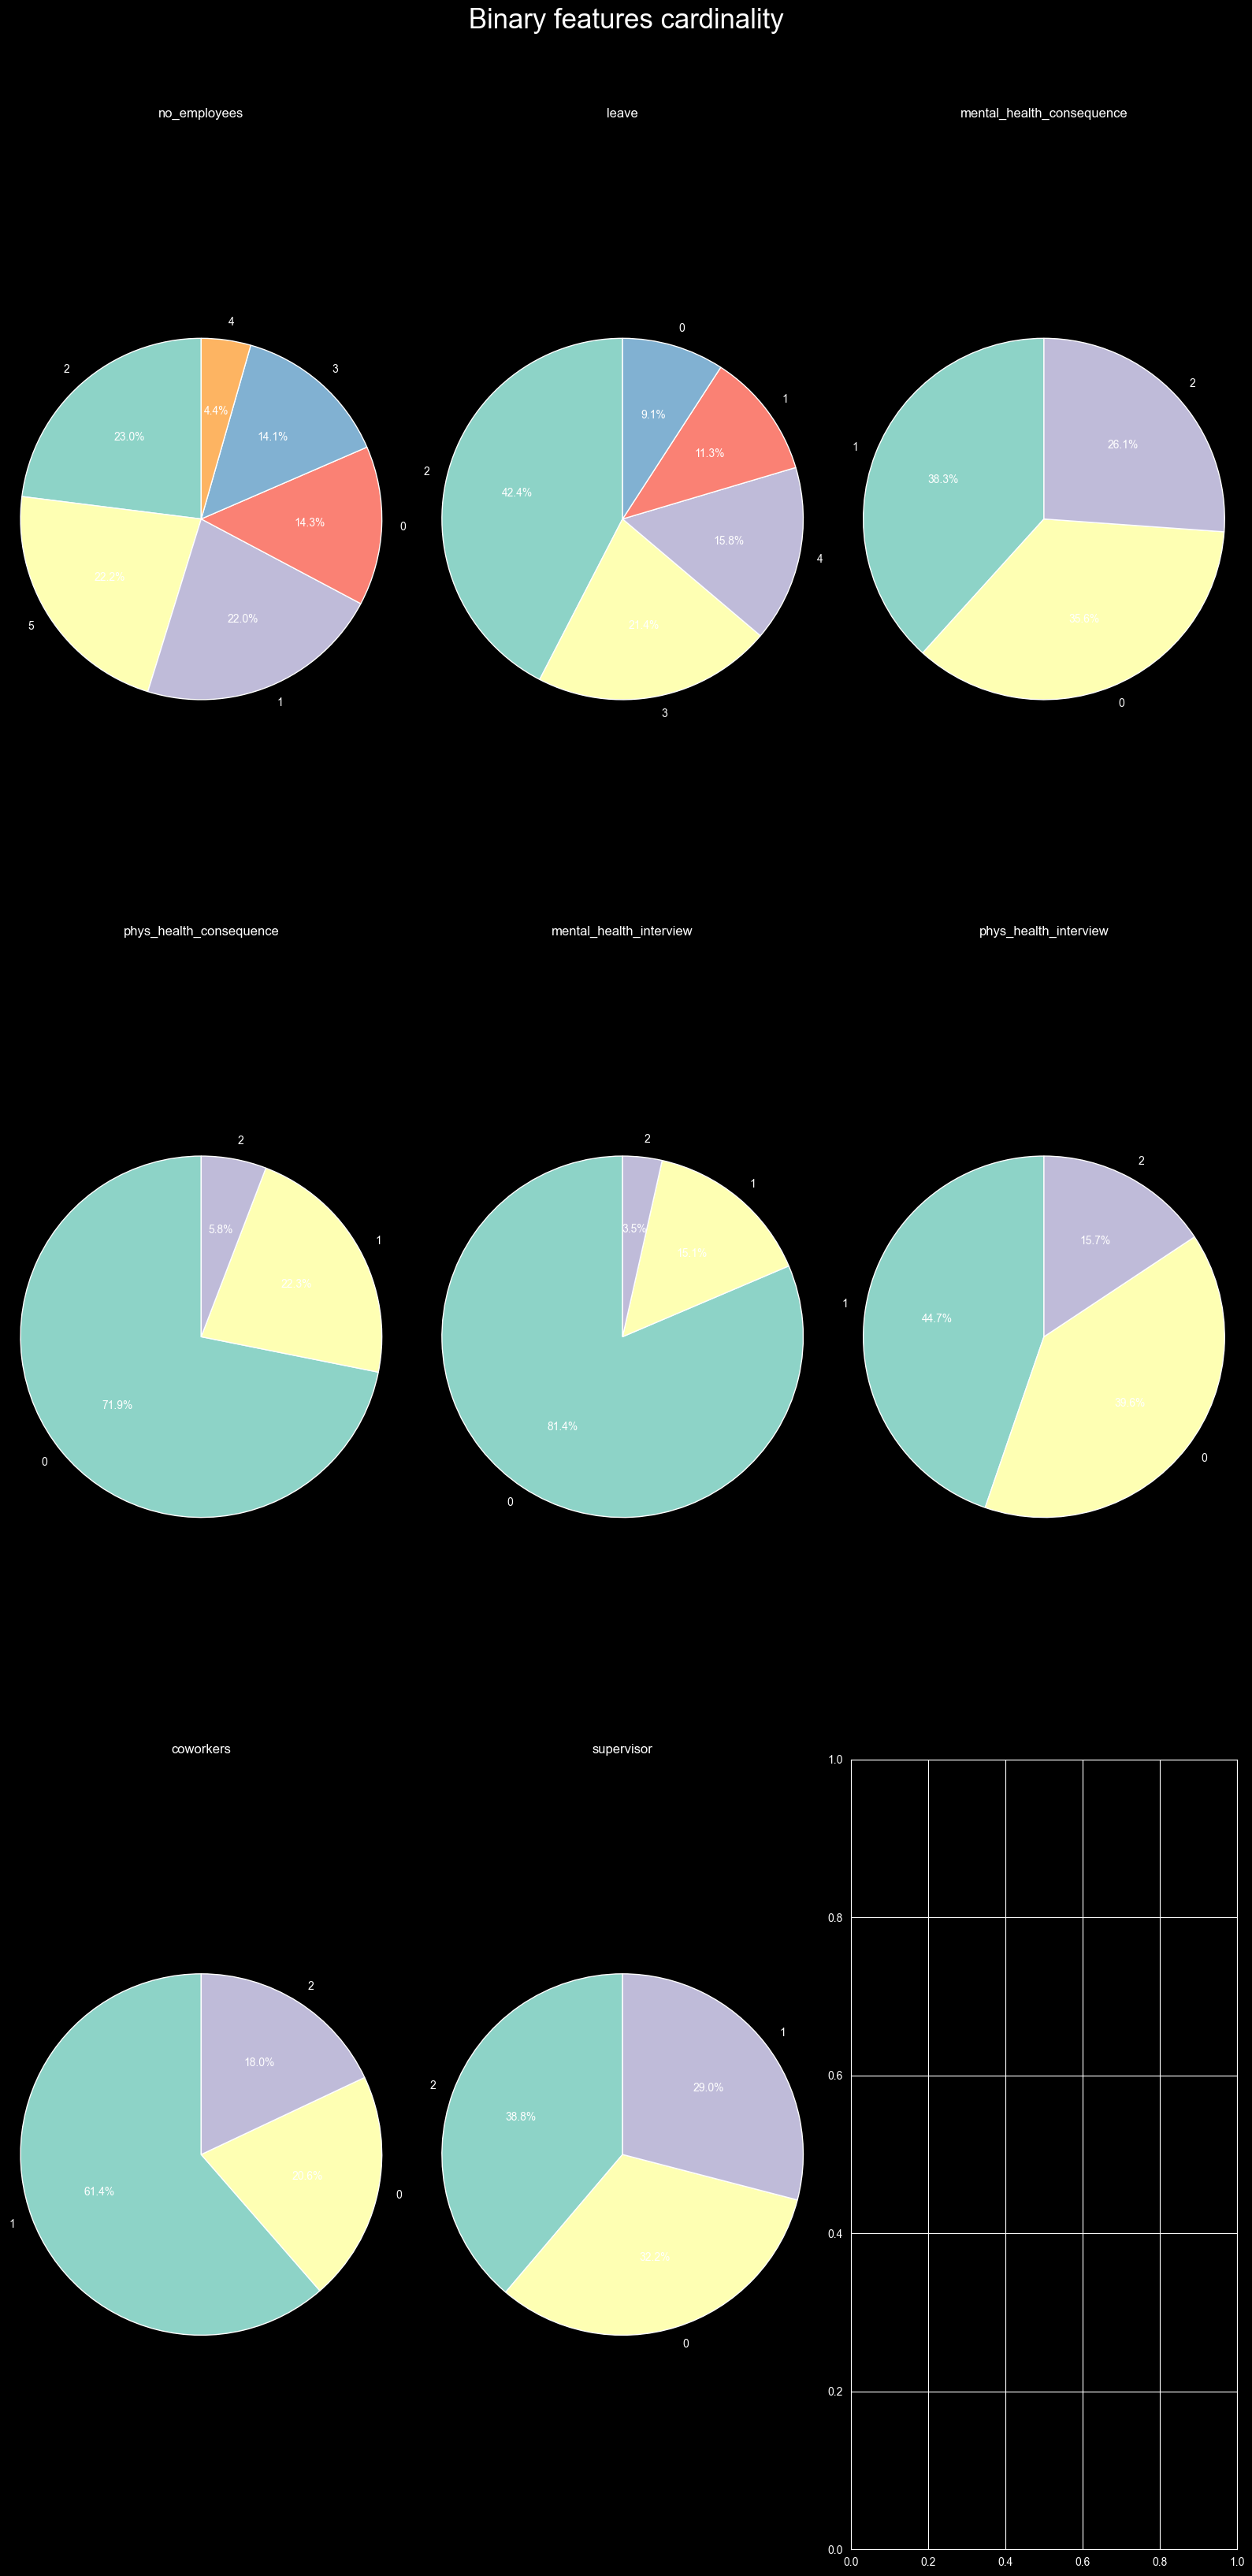

In [57]:
nrows, ncols = 3, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 32))
axes = axes.flat

for ax, col in zip(axes, ordinal_cols):
    sizes = data[col].value_counts()
    labels = sizes.index.astype(str)

    ax.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90)
    ax.set_title(col)
    ax.axis("equal")

fig.suptitle("Binary features cardinality", fontsize=25, y=1.02)
plt.tight_layout()
plt.show()

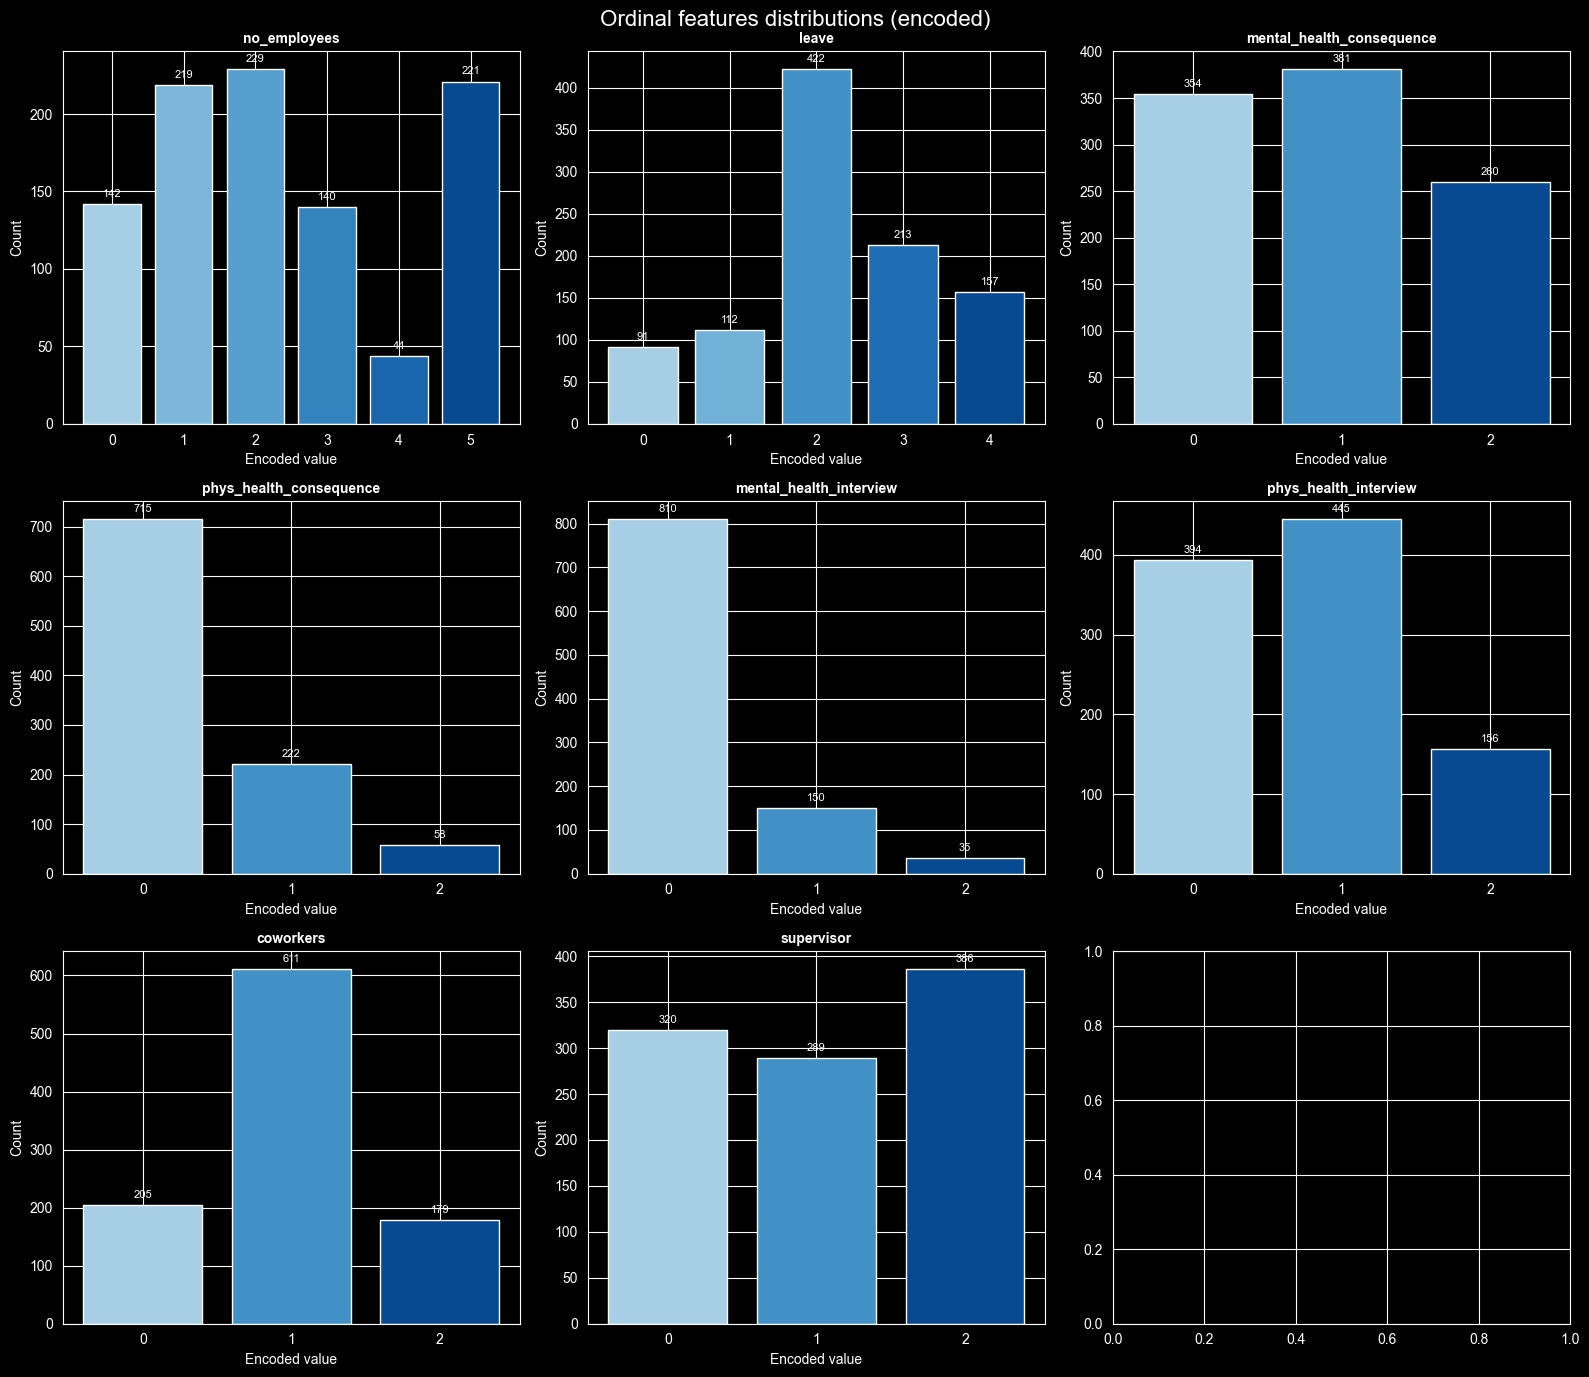

In [58]:
nrows, ncols = 3, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 14))
axes = axes.flat

for ax, col in zip(axes, ordinal_cols):
    counts = data[col].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values,
           color=plt.cm.Blues(np.linspace(0.35, 0.9, len(counts))),
           edgecolor="white")
    ax.set_title(col, fontsize=10, fontweight="bold")
    ax.set_ylabel("Count")
    ax.set_xlabel("Encoded value")
    for i, v in enumerate(counts.values):
        ax.text(i, v + counts.max() * 0.02, str(v), ha="center", fontsize=8)

fig.suptitle("Ordinal features distributions (encoded)", fontsize=16)
plt.tight_layout()
plt.show()